Number of bands: 3
Width: 1300
Height: 1300
Data type of the first band: uint16
Coordinate Reference System (CRS): EPSG:4326
Geotransform (affine transformation matrix): | 0.00, 0.00, 2.29|
| 0.00,-0.00, 49.03|
| 0.00, 0.00, 1.00|
Spatial bounds: BoundingBox(left=2.29346639993, bottom=49.0248909, right=2.29697639993, top=49.0284009)
Shape of the band data: (1300, 1300)
Minimum value in the band: 77
Maximum value in the band: 446
(1300, 1300, 3)


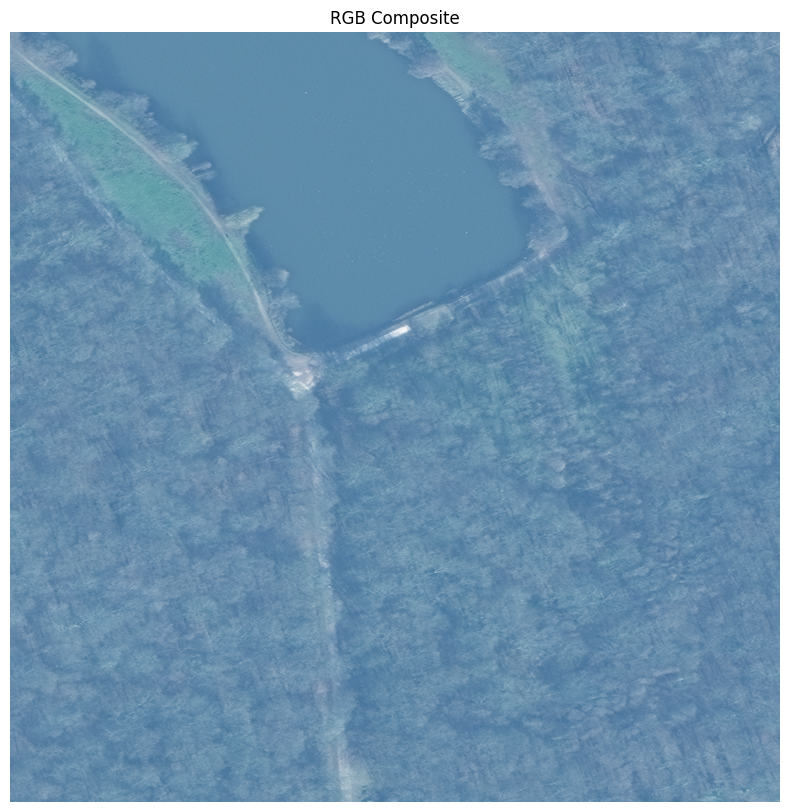

In [19]:
import rasterio

# Specify the path to your .tif file
file_number = '489'
file_path = 'data/SpaceNet_Roads_Sample/AOI_3_Paris_Roads_Sample/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img' + file_number + '.tif' 

# Open the raster dataset
with rasterio.open(file_path) as src:
    # 'src' is a Rasterio dataset object

    # Access basic information about the dataset
    print(f"Number of bands: {src.count}")
    print(f"Width: {src.width}")
    print(f"Height: {src.height}")
    print(f"Data type of the first band: {src.dtypes[0]}")
    print(f"Coordinate Reference System (CRS): {src.crs}")
    print(f"Geotransform (affine transformation matrix): {src.transform}")
    print(f"Spatial bounds: {src.bounds}")

    # Read the raster data for a specific band (e.g., the first band)
    band_data = src.read(1)  # Band indices are 1-based

    # 'band_data' is a NumPy array containing the pixel values of the band
    print(f"Shape of the band data: {band_data.shape}")
    print(f"Minimum value in the band: {band_data.min()}")
    print(f"Maximum value in the band: {band_data.max()}")

    # You can now work with the 'band_data' NumPy array for further analysis
    # For example, you could use matplotlib to display the image:
    import matplotlib.pyplot as plt
    import numpy as np
    red = src.read(1) / np.max(src.read(1))
    green = src.read(2) / np.max(src.read(2))
    blue = src.read(3) / np.max(src.read(3))

    rgb = np.stack((red, green, blue), axis=-1)
    print(rgb.shape)

    # Display the RGB composite
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb)
    plt.title("RGB Composite")
    plt.axis('off')
    plt.show()


labels.columns:  Index(['bridge_typ', 'heading', 'lane_numbe', 'lane_number', 'one_way_ty',
       'paved', 'road_id', 'road_type', 'origarea', 'origlen', 'partialDec',
       'truncated', 'geometry'],
      dtype='object')
labels.dtypes:  bridge_typ       object
heading          object
lane_numbe       object
lane_number      object
one_way_ty       object
paved            object
road_id           int32
road_type        object
origarea          int32
origlen         float64
partialDec        int32
truncated         int32
geometry       geometry
dtype: object


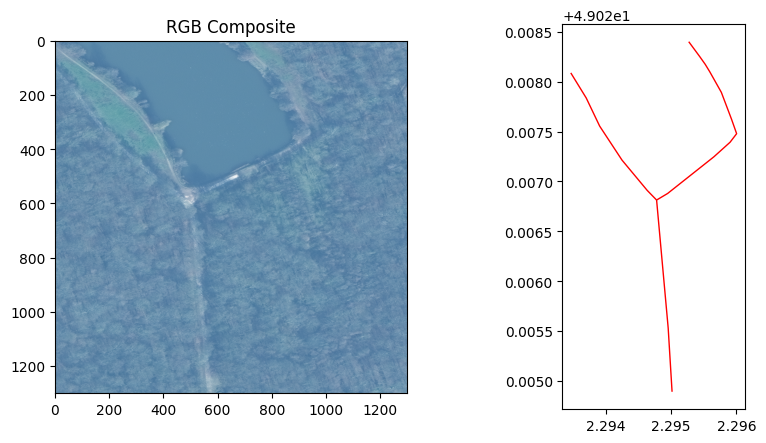

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show as rastershow

# Specify the path to your GeoJSON file
geojson_path = 'data/SpaceNet_Roads_Sample/AOI_3_Paris_Roads_Sample/geojson/spacenetroads/spacenetroads_AOI_3_Paris_img' + file_number + '.geojson'

labels = gpd.read_file(geojson_path)
print("labels.columns: ", labels.columns)
print("labels.dtypes: ", labels.dtypes)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title("RGB Composite")
# plt.axis('off')

ax = plt.subplot(1, 2, 2)
labels.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1)
plt.show()


labels:    bridge_typ heading lane_numbe lane_number one_way_ty paved  road_id  \
0          2       0          2           2          2     2      248   
1          2       0          2           2          2     2     3130   

  road_type  origarea   origlen  partialDec  truncated  \
0         6         0  0.009015           1          0   
1         6         0  0.003562           1          0   

                                            geometry  
0  LINESTRING (2.29527 49.0284, 2.29528 49.0284, ...  
1  LINESTRING (2.29347 49.02809, 2.2937 49.02784,...  
polygons:  <GeometryArray>
[<LINESTRING (2.295 49.028, 2.295 49.028, 2.295 49.028, 2.296 49.028, 2.296 4...>, <LINESTRING (2.293 49.028, 2.294 49.028, 2.294 49.028, 2.294 49.027, 2.295 4...>]
Length: 2, dtype: geometry
rasterized.shape: (1300, 1300)


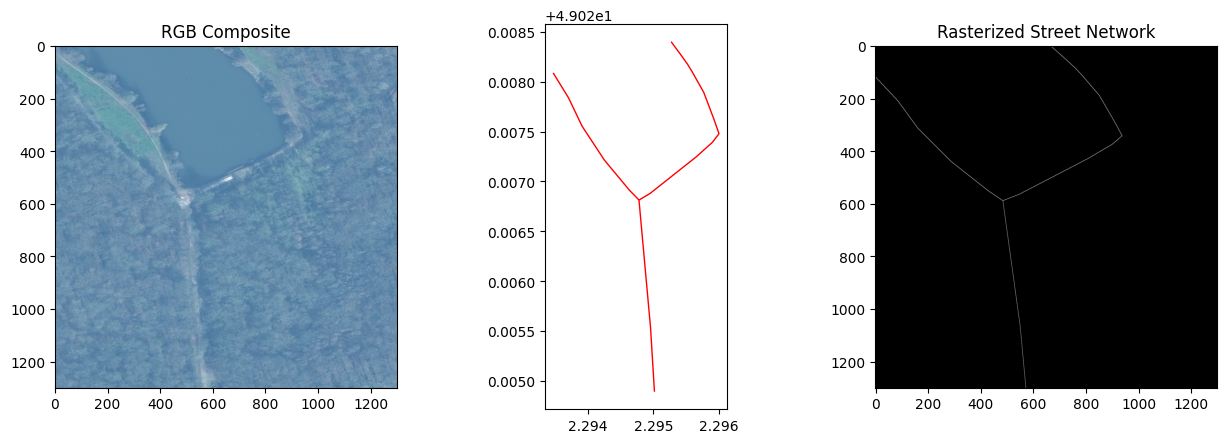

In [33]:
# rasterize street network
from rasterio.features import rasterize
from rasterio.transform import from_origin
from rasterio.enums import Resampling
import numpy as np
from rasterio import open as rio_open
# Specify the path to your .tif file
file_number = '489'
file_path = 'data/SpaceNet_Roads_Sample/AOI_3_Paris_Roads_Sample/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img' + file_number + '.tif'

with rio_open(file_path) as src:
    meta = src.meta.copy()
    transform = src.transform
    height, width = src.shape
    crs = src.crs
    bounds = src.bounds
    pixel_size_hor = (bounds.right - bounds.left) / width
    pixel_size_vert = (bounds.top - bounds.bottom) / height
    # print("meta: ", meta)
    # print("transform: ", transform)
    # print("height, width: ", height, width)
    # print("crs: ", crs)
    # print("bounds: ", bounds)
    # print("pixel_size_hor: ", pixel_size_hor)
    # print("pixel_size_vert: ", pixel_size_vert)

# Get the labels from the GeoDataFrame
labels = gpd.read_file(geojson_path)
print("labels: ", labels)
# Convert the labels to a list of polygons
polygons = labels.geometry.values
print("polygons: ", polygons)
# Create a new raster with the same dimensions as the original raster
raster = np.zeros((height, width), dtype=np.uint8)
# Rasterize the polygons
rasterized = rasterize(
    [(geom, 1) for geom in polygons],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    all_touched=True,
    dtype='uint8'
)
print(f"rasterized.shape: {rasterized.shape}")
# show the rasterized image
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(rgb)
plt.title("RGB Composite")
# plt.axis('off')
ax = plt.subplot(1, 3, 2)
labels.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=1)

plt.subplot(1, 3, 3)
plt.imshow(rasterized, cmap='gray')
plt.title("Rasterized Street Network")
# plt.axis('off')
plt.show()

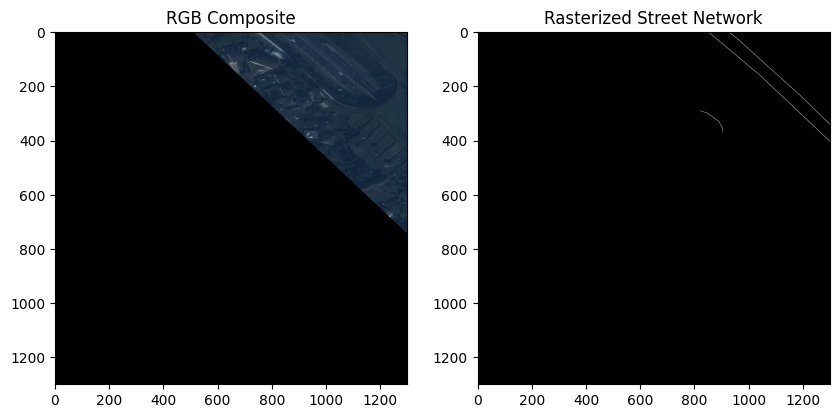

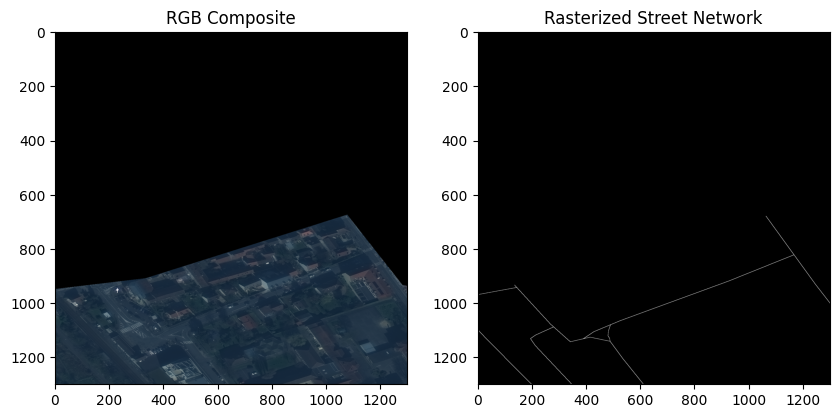

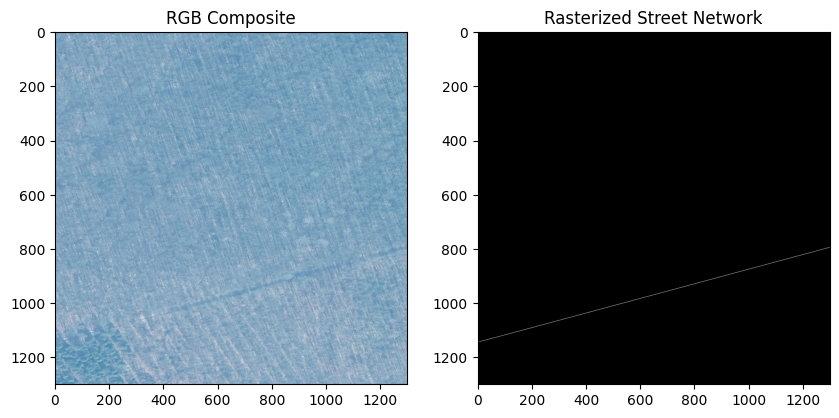

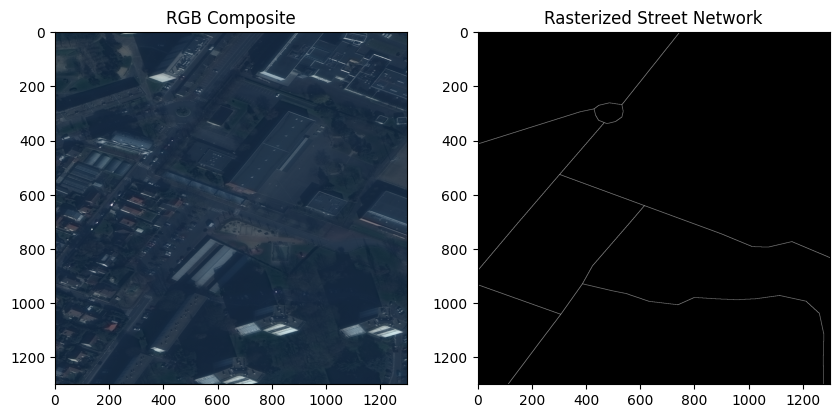

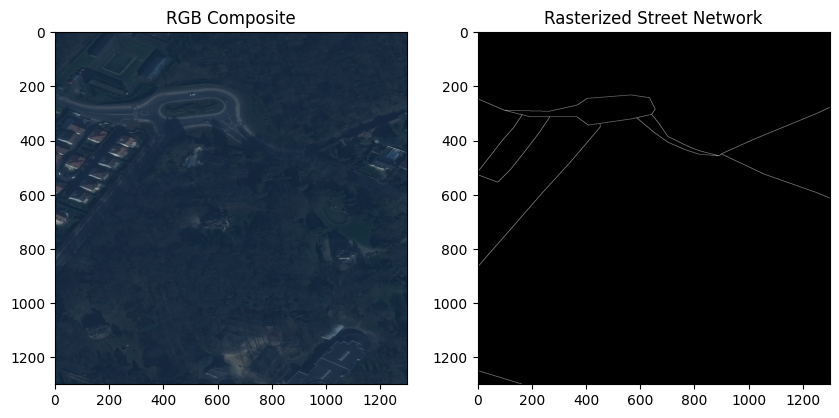

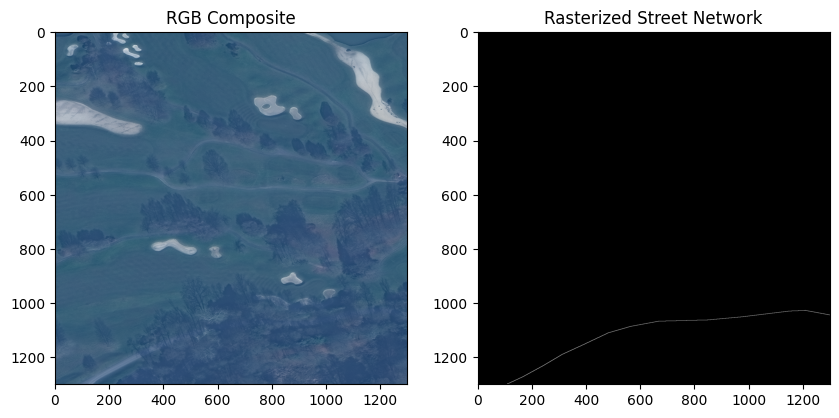

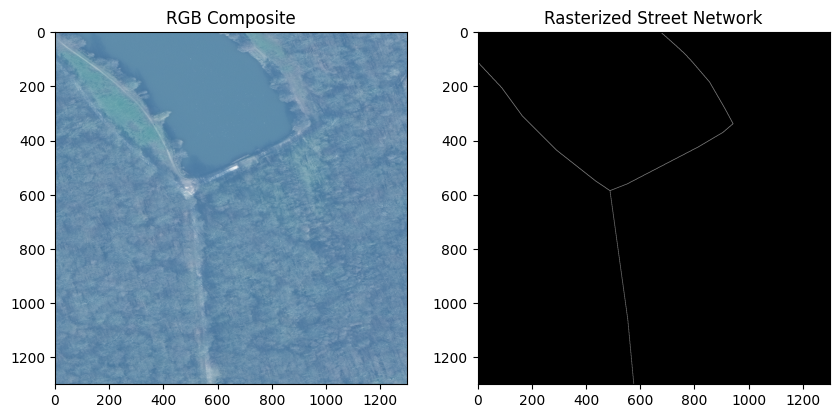

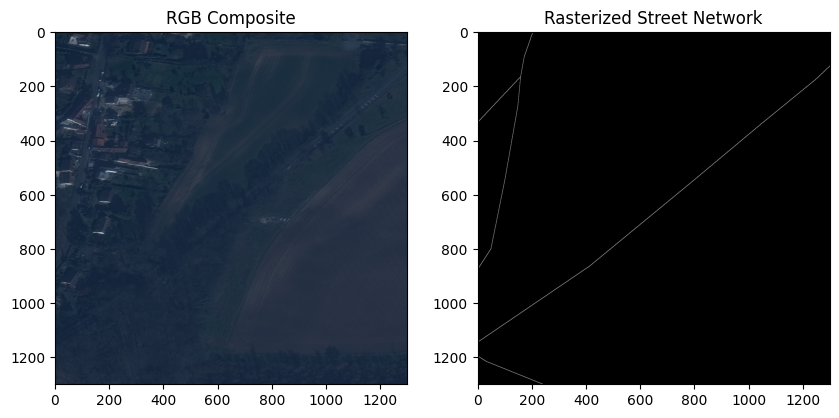

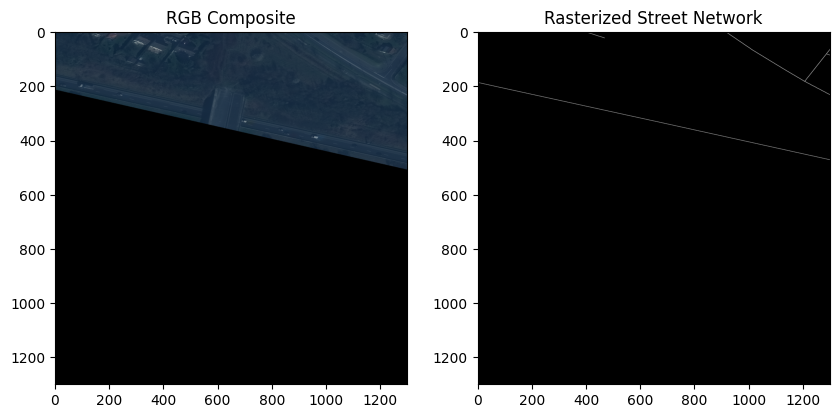

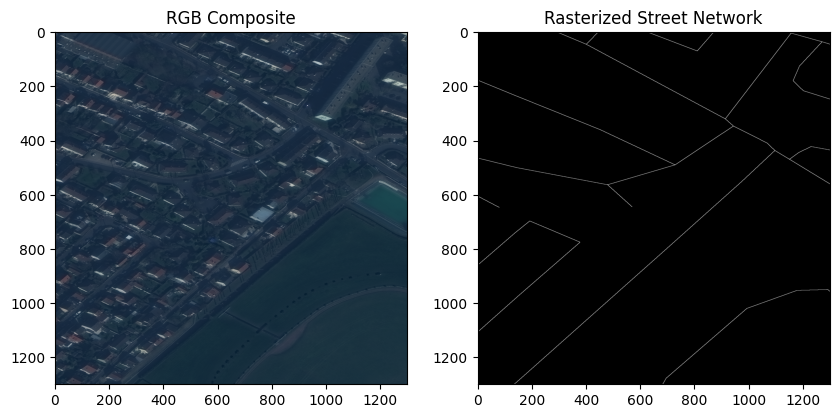

In [29]:
import os
import re
import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.features import rasterize
import tensorflow as tf

def get_image_and_label(image_number):
  # Load the image
  image_path = f'data/SpaceNet_Roads_Sample/AOI_3_Paris_Roads_Sample/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img{image_number}.tif'
  with rasterio.open(image_path) as src:
    red = src.read(1) / np.max(src.read(1))
    green = src.read(2) / np.max(src.read(2))
    blue = src.read(3) / np.max(src.read(3))
    image = np.stack((red, green, blue), axis=-1)
    transform = src.transform
    image_crs = src.crs
    out_shape = src.shape  # Get the image dimensions for rasterization

  # Load the label
  label_path = f'data/SpaceNet_Roads_Sample/AOI_3_Paris_Roads_Sample/geojson/spacenetroads/spacenetroads_AOI_3_Paris_img{image_number}.geojson'
  labels = gpd.read_file(label_path)

  # Reproject the labels to the image's CRS if they are different
  if labels.crs != image_crs:
    labels = labels.to_crs(image_crs)

  # Rasterize the GeoJSON using the image's transform and shape
  rasterized = rasterize(
      shapes=[(geom, 1) for geom in labels.geometry],
      out_shape=out_shape,
      transform=transform,
      fill=0,
      dtype=np.uint8,
      all_touched=True 
  )
  label = tf.convert_to_tensor(rasterized, dtype=tf.uint8)
  return image, label

# Load the SpaceNet Roads dataset
image_numbers = []
for filename in os.listdir('data/SpaceNet_Roads_Sample/AOI_3_Paris_Roads_Sample/RGB-PanSharpen'):
    if filename.endswith(".tif") and "RGB-PanSharpen_AOI_3_Paris_img" in filename:
      match = re.search(r"img(\d+)\.tif", filename)
      if match:
        image_numbers.append(match.group(1))

images = []
labels = []

for image_number in image_numbers:
  image, label = get_image_and_label(image_number)

  images.append(image)
  labels.append(label)

  # plot both
  plt.figure(figsize=(10, 5))
  plt.subplot(1, 2, 1)
  plt.imshow(image)
  plt.title("RGB Composite")
  plt.subplot(1, 2, 2)
  plt.imshow(label, cmap='gray')
  plt.title("Rasterized Street Network")
  plt.show()
